# IMDb Top 1000 Movies – Exploratory Data Analysis (EDA)

This project analyzes the IMDb Top 1000 movies dataset to extract meaningful business insights using Python.

**Import Libraries**

In [1]:
# for data manipulation
import pandas as pd

# for plotting graphs and visualization
import matplotlib.pyplot as plt


**Dataset Loading**

In [2]:
# load the data 
df = pd.read_csv("movie-data.csv")

**Dataset First View**

In [3]:
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


**Dataset rows and column count**

In [4]:
# check the shape of data
print("Number of Rows ",df.shape[0])
print("Number of Columns ",df.shape[1])

Number of Rows  1000
Number of Columns  16


**Dataset Information**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [6]:
# Describe Dataset
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


# Data Cleaning

**Making data ready to analysis**

In [7]:
# Type Conversion and Handling Missing Values
# Drop Duplicates
def clean_dataframe(df):
    """Clean and prepare the movie dataset."""
    df = df.copy()
    
    # Released Year type conversion
    df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce').astype('Int64')
   
    # Extract runtime using regex
    df['Runtime'] = df['Runtime'].str.extract(r'(\d+)').astype('Int64')
    
    # Clean gross with regex pass
    df['Gross'] = df['Gross'].astype(str).str.replace(r'[$,€₹,]', '', regex=True)
    df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')
    
    # Handle missing values efficiently
    df['Certificate'] = df['Certificate'].fillna(df['Certificate'].mode()[0])
    df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())
    df['Gross'] = df['Gross'].fillna(df['Gross'].median())
    
    return df.dropna(subset=['Released_Year']).drop_duplicates()


In [8]:
# Load and Clean Data
df = pd.read_csv("movie-data.csv")
df = clean_dataframe(df)

# Verify cleaning worked
print(f"Shape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nData Type:\n{df.dtypes}")

Shape: (999, 16)

Missing Values:
Poster_Link      0
Series_Title     0
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Overview         0
Meta_score       0
Director         0
Star1            0
Star2            0
Star3            0
Star4            0
No_of_Votes      0
Gross            0
dtype: int64

Data Type:
Poster_Link       object
Series_Title      object
Released_Year      Int64
Certificate       object
Runtime            Int64
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross            float64
dtype: object


# Exploratory Data Analysis

In [9]:
# Highest rating movie
high_rated_movie = df[df["IMDB_Rating"] == df["IMDB_Rating"].max()]
print("High Rating Movie:")
high_rated_movie[["Series_Title","IMDB_Rating"]]

High Rating Movie:


,Series_Title,IMDB_Rating
0,The Shawshank Redemption,9.3


In [10]:
# Lowest rating movie
low_rated_movie = df[df["IMDB_Rating"] == df["IMDB_Rating"].min()]
print("Lowest Rating Movie:")
low_rated_movie[["Series_Title","IMDB_Rating"]]



Lowest Rating Movie:


,Series_Title,IMDB_Rating
877,Dark Waters,7.6
878,Searching,7.6
879,Once Upon a Time... in Hollywood,7.6
880,Nelyubov,7.6
881,The Florida Project,7.6
...,...,...
995,Breakfast at Tiffany's,7.6
996,Giant,7.6
997,From Here to Eternity,7.6
998,Lifeboat,7.6


--> In IMDB Movie Dataset, 

*  **highest rating 9.3**

*  **lowest rating 7.6**


In [11]:
# Highest Rating Movies with Highest Votes(most liked movies)
filtered_rating = df["IMDB_Rating"] > 8.5
filtered_votes = df["No_of_Votes"] > 1000000
highest_rated_movie = df[filtered_rating & filtered_votes]
print("Movies with high rating and votes(most liked movies):")
highest_rated_movie[["Series_Title", "Genre","IMDB_Rating", "No_of_Votes","Gross"]]

Movies with high rating and votes(most liked movies):


,Series_Title,Genre,IMDB_Rating,No_of_Votes,Gross
0,The Shawshank Redemption,Drama,9.3,2343110,28341469.0
1,The Godfather,"Crime, Drama",9.2,1620367,134966411.0
2,The Dark Knight,"Action, Crime, Drama",9.0,2303232,534858444.0
3,The Godfather: Part II,"Crime, Drama",9.0,1129952,57300000.0
5,The Lord of the Rings: The Return of the King,"Action, Adventure, Drama",8.9,1642758,377845905.0
6,Pulp Fiction,"Crime, Drama",8.9,1826188,107928762.0
7,Schindler's List,"Biography, Drama, History",8.9,1213505,96898818.0
8,Inception,"Action, Adventure, Sci-Fi",8.8,2067042,292576195.0
9,Fight Club,Drama,8.8,1854740,37030102.0
10,The Lord of the Rings: The Fellowship of the Ring,"Action, Adventure, Drama",8.8,1661481,315544750.0


In [12]:
# Highest Rated Movie per Year
highest_rated_per_year = df.loc[
    df.groupby("Released_Year")["IMDB_Rating"].idxmax()
]

# Sort by year
highest_rated_per_year = highest_rated_per_year.sort_values("Released_Year")

highest_rated_per_year[["Released_Year", "Series_Title", "Genre","IMDB_Rating"]]


,Released_Year,Series_Title,Genre,IMDB_Rating
321,1920,Das Cabinet des Dr. Caligari,"Fantasy, Horror, Mystery",8.1
127,1921,The Kid,"Comedy, Drama, Family",8.3
568,1922,Nosferatu,"Fantasy, Horror",7.9
194,1924,Sherlock Jr.,"Action, Comedy, Romance",8.2
193,1925,The Gold Rush,"Adventure, Comedy, Drama",8.2
...,...,...,...,...
56,2016,Kimi no na wa.,"Animation, Drama, Fantasy",8.4
54,2017,Ayla: The Daughter of War,"Biography, Drama, History",8.4
53,2018,Capharnaüm,Drama,8.4
19,2019,Gisaengchung,"Comedy, Drama, Thriller",8.6


In [13]:
# Most Earning movie
top_grossing = df[df["Gross"] == df["Gross"].max()]
print("Most Earning Movie:")
top_grossing[["Series_Title", "Gross"]]

Most Earning Movie:


,Series_Title,Gross
477,Star Wars: Episode VII - The Force Awakens,936662225.0


GENRE ANALYSIS SUMMARY
Most common genre:  Drama (434 movies)
Least common in top : Biography (88 movies)
Top 3 genres account for 35.3% of all genre appearances


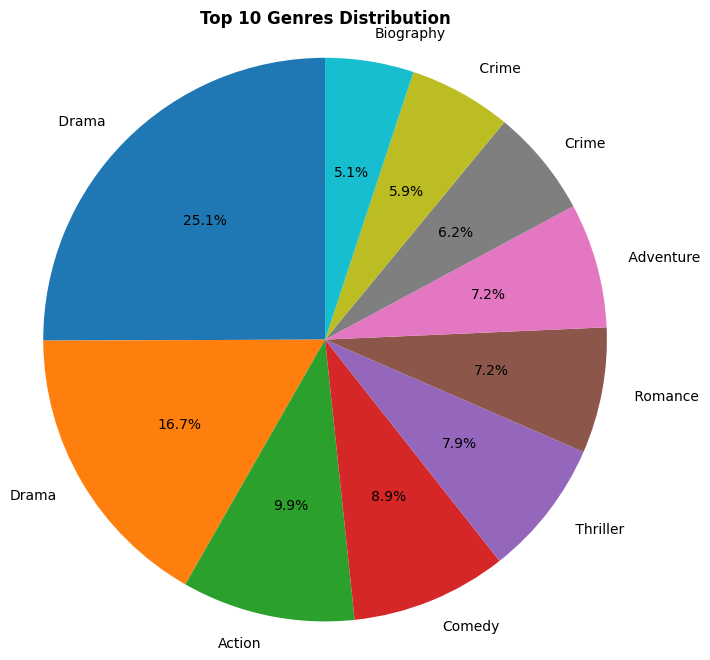

In [14]:
# Genre Analysis
def analyze_genres(df):
    """Process and analyze genre distribution."""
    # Split and explode
    genres = df['Genre'].str.split(',').explode()
    genre_counts = genres.value_counts()
    top_genres = genre_counts.head(10)
    
    # Visualization
    plt.figure(figsize=(8, 8))
    plt.pie(top_genres, labels=top_genres.index, autopct='%1.1f%%', 
        startangle=90)
    plt.title('Top 10 Genres Distribution', fontweight='bold')
    plt.axis('equal')
    
    # Print summary statistics
    print("=" * 50)
    print("GENRE ANALYSIS SUMMARY")
    print("=" * 50)
    print(f"Most common genre: {top_genres.index[0]} ({top_genres.values[0]} movies)")
    print(f"Least common in top : {top_genres.index[-1]} ({top_genres.values[-1]} movies)")
    print(f"Top 3 genres account for {top_genres.values[:3].sum() / genre_counts.sum() * 100:.1f}% of all genre appearances")

    plt.show()
    
    return genre_counts

# Plot the Pie Chart
genre_counts = analyze_genres(df)


SCATTER PLOT ANALYSIS
 Correlation coefficient: 0.495
 Positive correlation: Higher rated movies tend to get more votes

 Most voted movie: The Shawshank Redemption
    Rating: 9.3, Votes: 2.3M


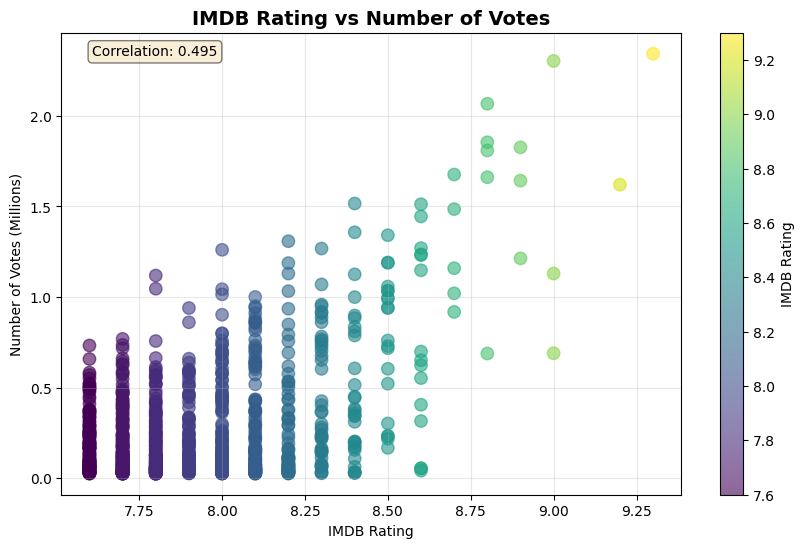

In [15]:
# Rating and Votes Analysis
def plot_rating_vs_votes(df):
    """Create scatter plot of IMDB rating vs number of votes."""
    
    # Converting votes count from raw numbers to millions for easier reading
    votes_millions = df['No_of_Votes'] / 1_000_000
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        df['IMDB_Rating'],    # X-axis values
        votes_millions,       # Y-axis values
        alpha=0.6,            # For Transparency
        c=df['IMDB_Rating'],  # Color by rating
        cmap='viridis',       # Color Scheme(dark=low, bright=high)
        s=80                  # Size of Points
    )
    
    plt.colorbar(scatter, label='IMDB Rating')
    plt.title('IMDB Rating vs Number of Votes', fontsize=14, fontweight='bold')
    plt.xlabel('IMDB Rating')
    plt.ylabel('Number of Votes (Millions)')
    plt.grid(True, alpha=0.3)
    
    # Add correlation annotation
    corr = df['IMDB_Rating'].corr(df['No_of_Votes'])
    plt.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Print Insights
    print("\n" + "=" * 60)
    print("SCATTER PLOT ANALYSIS")
    print("=" * 60)
    print(f" Correlation coefficient: {corr:.3f}")
    
    if corr > 0.3:
        print(" Positive correlation: Higher rated movies tend to get more votes")
    elif corr < -0.3:
        print(" Negative correlation: Higher rated movies tend to get FEWER votes")
    else:
        print(" No strong correlation: Rating doesn't predict vote count")
    
    print(f"\n Most voted movie: {df.loc[df['No_of_Votes'].idxmax(), 'Series_Title']}")
    print(f"    Rating: {df.loc[df['No_of_Votes'].idxmax(), 'IMDB_Rating']}, Votes: {df['No_of_Votes'].max()/1e6:.1f}M")
    
    return corr
#Ploting Scatter Plot 
corr = plot_rating_vs_votes(df)

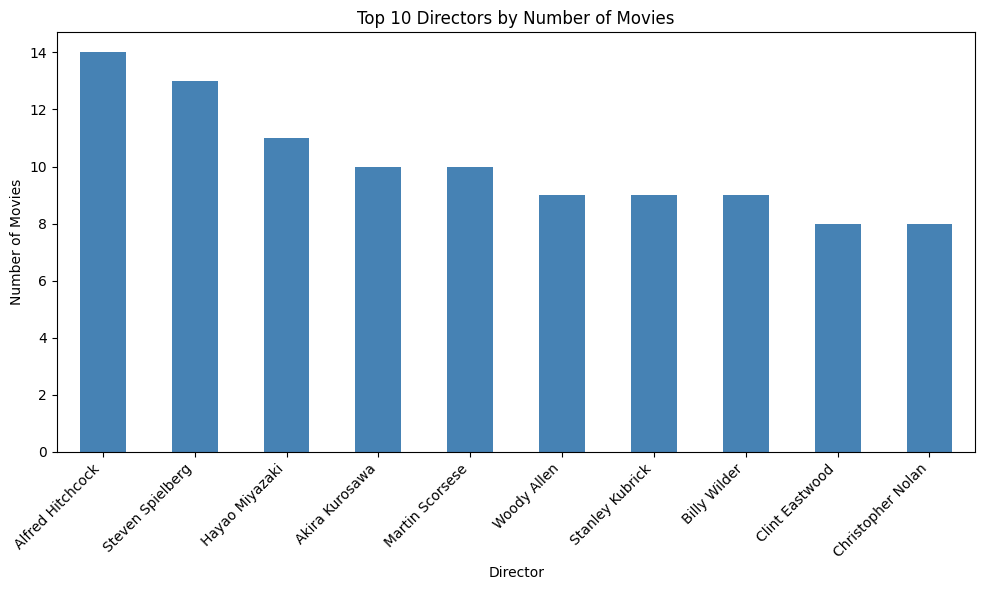

ANALYSIS

 TOP DIRECTOR STATS:
Most movies: Alfred Hitchcock (14 movies)
2nd place: Steven Spielberg (13 movies)
3rd place: Hayao Miyazaki (11 movies)

 GAP ANALYSIS:
Difference between #1 and #2: 1 movies
Difference between #9 and #10: 0 movies

 CONCENTRATION:
Top 3 directors make up 37.6% of top 10 movies


In [16]:
# Directors Analysis
# Get top 10 directors
top_directors = df['Director'].value_counts().head(10)

# Create bar chart
plt.figure(figsize=(10, 6))
top_directors.plot.bar(color='steelblue')
plt.title('Top 10 Directors by Number of Movies')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# print insights
print("ANALYSIS")
print("=" * 50)

# Get the actual numbers
print(f"\n TOP DIRECTOR STATS:")
print(f"Most movies: {top_directors.index[0]} ({top_directors.values[0]} movies)")
print(f"2nd place: {top_directors.index[1]} ({top_directors.values[1]} movies)")
print(f"3rd place: {top_directors.index[2]} ({top_directors.values[2]} movies)")

# Check the drop-off
drop_1_to_2 = top_directors.values[0] - top_directors.values[1]
drop_9_to_10 = top_directors.values[8] - top_directors.values[9]

print(f"\n GAP ANALYSIS:")
print(f"Difference between #1 and #2: {drop_1_to_2} movies")
print(f"Difference between #9 and #10: {drop_9_to_10} movies")

# Calculate percentage
top_3_total = top_directors.values[:3].sum()
top_10_total = top_directors.values.sum()
print(f"\n CONCENTRATION:")
print(f"Top 3 directors make up {top_3_total/top_10_total*100:.1f}% of top 10 movies")

# BUSINESS INSIGHTS & RECOMMENDATIONS

*MOVIE DATA ANALYSIS: KEY BUSINESS INSIGHTS & RECOMMENDATIONS*

INSIGHT 1: GENRE DOMINANCE

 * Drama appears in 28.9% of top 1000 movies
 * Comedy appears in 15.5% of top 1000 movies

RECOMMENDATIONS:
 * Drama projects are more dominating
 * Prioritize acquiring Drama content
 * Highlight dramatic elements in promotions, even for mixed-genre films

INSIGHT 2: THE BLOCKBUSTER PARADOX

 * Most Earning Movie: Star Wars: Episode VII - The Force Awakens
 * Rating: 7.9 (vs avg: 7.95)
 * Gross:  936.7M

RECOMMENDATIONS:
 * High budget ≠ high quality. Balance portfolio with both blockbusters and art-house films
 * Allocate 70% to commercial projects, 30% to critically-oriented films

INSIGHT 3: AUDIENCE ENGAGEMENT

 * Correlation between rating and votes: 0.495
 * This is the positive correlation that indicates high rated movies get more votes
 * High-rated movies (>8.5) avg votes: 1.2M
 * Lower-rated movies (<7.8) avg votes: 0.2M

RECOMMENDATIONS:
 * Higher ratings generate 3x more audience votes/interaction
 * Promote highly-rated films to drive platform engagement
 * Encourage reviews - rated films get more attention

INSIGHT 4: DIRECTOR PERFORMANCE
 * Alfred Hitchcock leads with 14 movies in the top 1000
 * Steven Spielberg follows closely with 13 movies
 * Top 3 directors (Hitchcock, Spielberg, Miyazaki) represent **37.6%** of the top 10 directors' contributions

